In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
from typing import Literal

# libs for Agents

from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent
from langchain.tools import tool

In [3]:
## coding,google_search, weather

class FlowState(BaseModel):
    question:str=Field(description="User Asked Question")
    category : Literal['coding','google_search','weather'] = Field(default="google_search")
    answer: str=Field(default="")

In [4]:
class QuestionCategory(BaseModel):
    category: Literal['coding','google_search','weather'] = Field(default="google_search",description="Question Category")

In [13]:
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [ ]:
### Define googleSearchAgent ,weatherAgent

search = GoogleSerperAPIWrapper()

search_tool = tool(
    name="google_search",
    func=search.run,
    description="Search Google for recent information"
)
google_agent=create_agent(
    model=llm,
    tools=[search_tool],
    system_prompt="You are a agent and can search for any questions on google."
)


# weatherAgent
@tool
def get_weather(city:str):
    """It provide real time weather detail for any city"""
    return f" The Weather in {city} is 35 degree celsius"

weather_agent=create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a agent and can provide real time weather details."
)

In [7]:
def check_question_category(state:FlowState)  ->FlowState:
    st_llm=llm.with_structured_output(QuestionCategory)
    res=st_llm.invoke(f"I want to know the category of my question, question is {state.question} and If you are not sure about category then just give 'google_search' as a category")
    
    state.category=res.category
    
    return state

In [8]:
def route(state:FlowState)  ->Literal['coding','google_search','weather']:
    return state.category

In [9]:
def coding_node(state:FlowState) ->FlowState:
    res=llm.invoke(f"You are coding expert:{state.question}")
    state.answer=res.content
    return state

def weather_node(state:FlowState) ->FlowState:
    res=weather_agent.invoke({"messages":[{"role":"user","content":state.question}]})
    state.answer=res["messages"][-1].content
    return state

def google_search_node(state:FlowState) ->FlowState:
    res=google_agent.invoke({"messages":[{"role":"user","content":state.question}]})
    state.answer=res["messages"][-1].content
    return state



In [10]:
graph=StateGraph(FlowState)

graph.add_node("check_question_category",check_question_category)
graph.add_node("coding", coding_node)
graph.add_node("weather", weather_node)
graph.add_node("google_search",google_search_node)


graph.add_edge(START,"check_question_category")
graph.add_conditional_edges("check_question_category",route)
graph.add_edge("coding", END)
graph.add_edge("weather", END)
graph.add_edge("google_search", END)


graph=graph.compile()



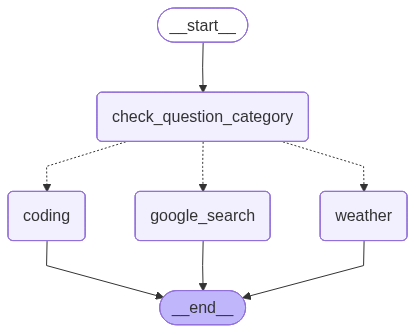

In [11]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [12]:
res=graph.invoke({"question":"who is salman khan?"})

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=run>{"query": "salman khan"}}'}}

In [ ]:
res

{'question': 'What is address of Codewithharry home ?',
 'category': 'google_search',
 'answer': 'I am not able to execute this request as it exceeds the limitations of the functions I have been given.'}